<a href="https://colab.research.google.com/github/carolyna-s/CS123A_Project/blob/main/CS123ATermProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning & Analysis on OSDR-47 & OSDR-48 Datasets

Datasets Used:


https://osdr.nasa.gov/bio/repo/data/studies/OSD-47

https://osdr.nasa.gov/bio/repo/data/studies/OSD-48



# Read in methods

In [ ]:
!pip install import_ipynb
import import_ipynb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 29.4 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.flush_and_unmount()
drive.mount("mnt",force_remount=True)

Drive not mounted, so nothing to flush and unmount.
Mounted at mnt


In [ ]:
m = __import__("mnt/MyDrive/Colab Notebooks/123A_Take2/projectmethods")
import seaborn as sns
import pandas as pd
# from itertools import zip_longest
# matplotlib.pyplot as plt
import scipy.stats as stats
import numpy as np
import re
import plotly.graph_objects as go
!pip install mygene
import mygene

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 43.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.5/144.5 kB 185.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 85.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.1/53.1 kB 163.7 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 590.8/590.8 kB 70.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.4/61.4 kB 173.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 154.8 MB/s eta 0:00:00
  Created wheel for pybiomart: filename=pybiomart-0.1-py3-none-any.whl size=14600 sha256=7382c8e94fc93c7b29694564dc2d12eba5e6cc554c8a0de38c23bc419bafd30c
  Stored in directory: /tmp/pip-ephem-wheel-cache-4mxax_26/wheels/ad/45

# Reading in OSDR data

In [ ]:
#define dictionaries
data=dict()
metadata=dict()

Reading in Metadata

In [ ]:

#OSDR-47
metadata['47']=m.read_meta_data('47')

#OSDR-48
metadata['48']=m.read_meta_data('48')
metadata['48'].head()

,Source Name,Sample Name,Characteristics[Organism],Term Source REF,Term Accession Number,Characteristics[Strain],Term Source REF.1,Term Accession Number.1,Characteristics[Material Type],Term Source REF.2,...,Parameter Value[exposure duration],Unit.5,Term Source REF.14,Term Accession Number.14,Parameter Value[ionizing radiation categorized by source],Term Source REF.15,Term Accession Number.15,Parameter Value[vehicle],Term Source REF.16,Term Accession Number.16
0,RR1_BSL_M4,Mmus_C57-6J_LVR_BSL_C_Rep1_M4,Mus musculus,NCBITAXON,http://purl.bioontology.org/ontology/NCBITAXON...,C57BL/6J,EFO,http://www.ebi.ac.uk/efo/EFO_0000606,Liver,MESH,...,NaN,Not Applicable,OSD,https://osdr.nasa.gov/,Not Applicable,OSD,https://osdr.nasa.gov/,Not Applicable,NCIT,http://purl.obolibrary.org/obo/NCIT_C48660
1,RR1_BSL_M5,Mmus_C57-6J_LVR_BSL_C_Rep2_M5,Mus musculus,NCBITAXON,http://purl.bioontology.org/ontology/NCBITAXON...,C57BL/6J,EFO,http://www.ebi.ac.uk/efo/EFO_0000606,Liver,MESH,...,NaN,Not Applicable,OSD,https://osdr.nasa.gov/,Not Applicable,OSD,https://osdr.nasa.gov/,Not Applicable,NCIT,http://purl.obolibrary.org/obo/NCIT_C48660
2,RR1_BSL_M7,Mmus_C57-6J_LVR_BSL_C_Rep3_M7,Mus musculus,NCBITAXON,http://purl.bioontology.org/ontology/NCBITAXON...,C57BL/6J,EFO,http://www.ebi.ac.uk/efo/EFO_0000606,Liver,MESH,...,NaN,Not Applicable,OSD,https://osdr.nasa.gov/,Not Applicable,OSD,https://osdr.nasa.gov/,Not Applicable,NCIT,http://purl.obolibrary.org/obo/NCIT_C48660
3,RR1_BSL_M8,Mmus_C57-6J_LVR_BSL_C_Rep4_M8,Mus musculus,NCBITAXON,http://purl.bioontology.org/ontology/NCBITAXON...,C57BL/6J,EFO,http://www.ebi.ac.uk/efo/EFO_0000606,Liver,MESH,...,NaN,Not Applicable,OSD,https://osdr.nasa.gov/,Not Applicable,OSD,https://osdr.nasa.gov/,Not Applicable,NCIT,http://purl.obolibrary.org/obo/NCIT_C48660
4,RR1_BSL_M10,Mmus_C57-6J_LVR_BSL_C_Rep5_M10,Mus musculus,NCBITAXON,http://purl.bioontology.org/ontology/NCBITAXON...,C57BL/6J,EFO,http://www.ebi.ac.uk/efo/EFO_0000606,Liver,MESH,...,NaN,Not Applicable,OSD,https://osdr.nasa.gov/,Not Applicable,OSD,https://osdr.nasa.gov/,Not Applicable,NCIT,http://purl.obolibrary.org/obo/NCIT_C48660


Getting Normalized Counts as a Dataframe

In [ ]:
data['47-normalized']=m.read_rnaseq_data('47_rna_seq_Normalized_Counts')
data['47-normalized'].tail()
#rows: gene exp values
#cols: mouse sample
data['48-normalized']=m.read_rnaseq_data('48_rna_seq_Normalized_Counts')
data['48-normalized'].tail()

,Unnamed: 0,Mmus_C57-6J_LVR_GC_I_Rep1_M31,Mmus_C57-6J_LVR_GC_I_Rep2_M32,Mmus_C57-6J_LVR_FLT_I_Rep1_M21,Mmus_C57-6J_LVR_FLT_I_Rep2_M22,Mmus_C57-6J_LVR_GC_C_Rep1_M36,Mmus_C57-6J_LVR_GC_C_Rep2_M37,Mmus_C57-6J_LVR_GC_C_Rep3_M38,Mmus_C57-6J_LVR_GC_C_Rep4_M39,Mmus_C57-6J_LVR_GC_C_Rep5_M40,Mmus_C57-6J_LVR_FLT_C_Rep1_M25,Mmus_C57-6J_LVR_FLT_C_Rep2_M26,Mmus_C57-6J_LVR_FLT_C_Rep3_M27,Mmus_C57-6J_LVR_FLT_C_Rep4_M28,Mmus_C57-6J_LVR_FLT_C_Rep5_M30
22191,ENSMUSG00000118353,45.600972,69.347685,66.541523,129.599453,121.333158,207.268147,216.190100,203.586925,159.630136,212.903516,138.128991,184.792447,176.055683,185.347476
22192,ENSMUSG00000118366,2391.935897,2322.733457,1498.010820,1854.811554,1801.150678,1916.382157,1713.025492,2306.411567,2099.440761,2156.654990,1465.599890,2005.315842,1889.948389,2318.810473
22193,ENSMUSG00000118383,9.949113,35.791670,79.620815,6.220717,10.601934,9.060909,2.604702,0.000000,9.092862,2.628466,4.682435,5.961110,5.302886,3.888450
22194,ENSMUSG00000118384,2.487308,0.000000,0.000000,1.036792,0.000000,0.000000,8.682336,0.929624,4.041270,1.314224,7.023561,2.384428,4.242307,0.000000
22195,ENSMUSG00000118386,0.000000,0.000000,1.137483,3.110415,1.177991,2.265224,4.341164,4.648055,0.000000,0.000000,0.000000,0.000000,2.121151,6.480614


# Reading in Histology Oil Red Staining Data

In [ ]:
#OSDR-47:
data['ORO-47']=m.read_phenotype_data('47','LSDS-29_Histology_OSD_47_Histology_TRANSFORMED')
print("Number of samples: ",str(len(data['ORO-47']['Sample name'].unique())))
data['ORO-47']['Source name']=data["ORO-47"]["Source name"].str.replace(" ","")
data['ORO-47']

Number of samples:  15


,Source name,Sample name,Space mission,Spaceflight,Dissection,HE file ID,ORO Positivity (%)
0,GC2,Mmus_C57-6T_LVR_GC_Rep1_G2,CASIS-rr1,Ground,Immediate,G4 GL19-21 HE,14.49
1,GC3,Mmus_C57-6T_LVR_GC_Rep2_G3,CASIS-rr1,Ground,Immediate,G4 GL19-21 HE,13.96
2,GC5,Mmus_C57-6T_LVR_GC_Rep3_G5,CASIS-rr1,Ground,Immediate,G4 GL22-23 HE,17.35
3,GC1,Mmus_C57-6T_LVR_GC_Rep4_G1,CASIS-rr1,Ground,Immediate,G4 GL19-21 HE,12.02
4,GC4,Mmus_C57-6T_LVR_GC_Rep5_G4,CASIS-rr1,Ground,Immediate,G4 GL22-23 HE,16.34
5,FLT1,Mmus_C57-6T_LVR_FLT_Rep1_F1,CASIS-rr1,Flight,Immediate,G5 GL24-26 HE,23.56
6,FLT2,Mmus_C57-6T_LVR_FLT_Rep2_F2,CASIS-rr1,Flight,Immediate,G5 GL24-26 HE,25.56
7,FLT4,Mmus_C57-6T_LVR_FLT_Rep3_F4,CASIS-rr1,Flight,Immediate,G5 GL27-28 HE,16.28
8,FLT3,Mmus_C57-6T_LVR_FLT_Rep4_F3,CASIS-rr1,Flight,Immediate,G5 GL24-26 HE,20.57
9,FLT5,Mmus_C57-6T_LVR_FLT_Rep5_F5,CASIS-rr1,Flight,Immediate,G5 GL27-28 HE,17.43


In [ ]:
#OSDR-48:
data['ORO-48']=m.read_phenotype_data('48','LSDS-2_Histology_OSD_48_Histology_TRANSFORMED')
print("Number of samples: ",str(len(data['ORO-48']['Sample name'].unique())))
data['ORO-48']['Source name']=data["ORO-48"]["Source name"].str.replace("RR1_","")
data['ORO-48']['Source name']=data["ORO-48"]["Source name"].str.replace("_M","")
data['ORO-48']

Number of samples:  24


,Source name,Sample name,Space mission,Spaceflight,Dissection,HE file ID,ORO Positivity (%)
0,BSL4,Mmus_C57-6J_LVR_BSL_C_Rep1_M4,RR1,Basal,Carcass,17-317.1 HE G1 1-2-3,10.41
1,BSL5,Mmus_C57-6J_LVR_BSL_C_Rep2_M5,RR1,Basal,Carcass,17-317.1 HE G1 1-2-3,22.29
2,BSL7,Mmus_C57-6J_LVR_BSL_C_Rep3_M7,RR1,Basal,Carcass,17-317.1 HE G1 1-2-3,2.09
3,BSL8,Mmus_C57-6J_LVR_BSL_C_Rep4_M8,RR1,Basal,Carcass,17-317.1 HE G1 4-5,8.36
4,BSL10,Mmus_C57-6J_LVR_BSL_C_Rep5_M10,RR1,Basal,Carcass,17-317.1 HE G1 4-5,3.30
5,VIV16,Mmus_C57-6J_LVR_VIV_C_Rep1_M16,RR1,Vivarium,Carcass,17-317.1 HE G2 6-7-8,16.97
6,VIV17,Mmus_C57-6J_LVR_VIV_C_Rep2_M17,RR1,Vivarium,Carcass,17-317.1 HE G2 6-7-8,14.98
7,VIV18,Mmus_C57-6J_LVR_VIV_C_Rep3_M18,RR1,Vivarium,Carcass,17-317.1 HE G2 6-7-8,13.07
8,VIV19,Mmus_C57-6J_LVR_VIV_C_Rep4_M19,RR1,Vivarium,Carcass,17-317.1 HE G2 9-10,1.44
9,VIV20,Mmus_C57-6J_LVR_VIV_C_Rep5_M20,RR1,Vivarium,Carcass,17-317.1 HE G2 9-10,7.89


# Defining Condition Mapping Criteria
Basal and Vivarium samples mapped to Ground condition
Any sample excluded from normalized RNA-seq data table indicates that that sample was not used for RNA-sequencing.


In [ ]:

df=data['47-normalized']
dfT = df.T
dfT.columns=dfT.iloc[0]
dfT=dfT.iloc[1:]
dfT.columns.name=None
dfT = dfT.reset_index().rename(columns={"index":"sample"})         #from m.run_deseq2
m.samples_to_conditions(dfT,metadata['47'],'Factor Value[Spaceflight]','Ground Control','Space Flight','Basal Control')

['Mmus_C57-6T_LVR_BSL_Rep1_B1' 'Mmus_C57-6T_LVR_BSL_Rep2_B2'
 'Mmus_C57-6T_LVR_BSL_Rep3_B3' 'Mmus_C57-6T_LVR_BSL_Rep4_B4'
 'Mmus_C57-6T_LVR_BSL_Rep5_B5' 'Mmus_C57-6T_LVR_GC_Rep4_G1'
 'Mmus_C57-6T_LVR_GC_Rep1_G2' 'Mmus_C57-6T_LVR_GC_Rep2_G3'
 'Mmus_C57-6T_LVR_GC_Rep5_G4' 'Mmus_C57-6T_LVR_GC_Rep3_G5'
 'Mmus_C57-6T_LVR_FLT_Rep1_F1' 'Mmus_C57-6T_LVR_FLT_Rep2_F2'
 'Mmus_C57-6T_LVR_FLT_Rep4_F3' 'Mmus_C57-6T_LVR_FLT_Rep3_F4'
 'Mmus_C57-6T_LVR_FLT_Rep5_F5' 'Pool of CASIS BC_GC_FLT']


,sample,condition
0,Mmus_C57-6T_LVR_BSL_Rep1_B1,0
1,Mmus_C57-6T_LVR_BSL_Rep2_B2,0
2,Mmus_C57-6T_LVR_BSL_Rep3_B3,0
3,Mmus_C57-6T_LVR_GC_Rep1_G2,0
4,Mmus_C57-6T_LVR_GC_Rep2_G3,0
5,Mmus_C57-6T_LVR_GC_Rep3_G5,0
6,Mmus_C57-6T_LVR_FLT_Rep1_F1,1
7,Mmus_C57-6T_LVR_FLT_Rep2_F2,1
8,Mmus_C57-6T_LVR_FLT_Rep3_F4,1


In [ ]:
#OSDR-48 MAP CONDITIONS

df=data['48-normalized']
dfT = df.T
dfT.columns=dfT.iloc[0]
dfT=dfT.iloc[1:]
dfT.columns.name=None
dfT = dfT.reset_index().rename(columns={"index":"sample"})         #from m.run_deseq2
m.samples_to_conditions(dfT,metadata['48'],'Factor Value[Spaceflight]','Ground Control','Space Flight','Basal Control','Vivarium Control')


['Mmus_C57-6J_LVR_BSL_C_Rep1_M4' 'Mmus_C57-6J_LVR_BSL_C_Rep2_M5'
 'Mmus_C57-6J_LVR_BSL_C_Rep3_M7' 'Mmus_C57-6J_LVR_BSL_C_Rep4_M8'
 'Mmus_C57-6J_LVR_BSL_C_Rep5_M10' 'Mmus_C57-6J_LVR_VIV_C_Rep1_M16'
 'Mmus_C57-6J_LVR_VIV_C_Rep2_M17' 'Mmus_C57-6J_LVR_VIV_C_Rep3_M18'
 'Mmus_C57-6J_LVR_VIV_C_Rep4_M19' 'Mmus_C57-6J_LVR_VIV_C_Rep5_M20'
 'Mmus_C57-6J_LVR_FLT_I_Rep1_M21' 'Mmus_C57-6J_LVR_FLT_I_Rep2_M22'
 'Mmus_C57-6J_LVR_FLT_C_Rep1_M25' 'Mmus_C57-6J_LVR_FLT_C_Rep2_M26'
 'Mmus_C57-6J_LVR_FLT_C_Rep3_M27' 'Mmus_C57-6J_LVR_FLT_C_Rep4_M28'
 'Mmus_C57-6J_LVR_FLT_C_Rep6_M29' 'Mmus_C57-6J_LVR_FLT_C_Rep5_M30'
 'Mmus_C57-6J_LVR_GC_I_Rep1_M31' 'Mmus_C57-6J_LVR_GC_I_Rep2_M32'
 'Mmus_C57-6J_LVR_GC_C_Rep6_M35' 'Mmus_C57-6J_LVR_GC_C_Rep1_M36'
 'Mmus_C57-6J_LVR_GC_C_Rep2_M37' 'Mmus_C57-6J_LVR_GC_C_Rep3_M38'
 'Mmus_C57-6J_LVR_GC_C_Rep4_M39' 'Mmus_C57-6J_LVR_GC_C_Rep5_M40'
 'RR1_GC_NASA+CASIS_LVR_POOL' 'RR1_GC_NASA_LVR_POOL'
 'RR1_BA_CASIS_LVR_POOL' 'RR1_FLT_NASA+CASIS_LVR_POOL'
 'RR1_FLT_NASA_LVR_POOL' 'RR1_BSL

,sample,condition
0,Mmus_C57-6J_LVR_GC_I_Rep1_M31,0
1,Mmus_C57-6J_LVR_GC_I_Rep2_M32,0
2,Mmus_C57-6J_LVR_FLT_I_Rep1_M21,1
3,Mmus_C57-6J_LVR_FLT_I_Rep2_M22,1
4,Mmus_C57-6J_LVR_GC_C_Rep1_M36,0
5,Mmus_C57-6J_LVR_GC_C_Rep2_M37,0
6,Mmus_C57-6J_LVR_GC_C_Rep3_M38,0
7,Mmus_C57-6J_LVR_GC_C_Rep4_M39,0
8,Mmus_C57-6J_LVR_GC_C_Rep5_M40,0
9,Mmus_C57-6J_LVR_FLT_C_Rep1_M25,1


# Filtering Genes with DGEA

In [ ]:
rna_seq_47=m.filter_by_dgea(data['47-normalized'],metadata['47'],pval=0.05,l2fc=0)
print('rna_seq_47 data shape', rna_seq_47.shape)

Fitting size factors...
... done in 0.03 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 25.35 seconds.

Fitting dispersion trend curve...
... done in 0.63 seconds.

Fitting MAP dispersions...
... done in 30.42 seconds.

Fitting LFCs...
... done in 15.17 seconds.

Calculating cook's distance...
... done in 0.03 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 7.00 seconds.



Log2 fold change & Wald test p-value: condition 0 vs 1
                        baseMean  log2FoldChange     lfcSE      stat  \
ENSMUSG00000000001   2647.889712       -0.003579  0.141372 -0.025314   
ENSMUSG00000000028     41.979262        0.318747  0.251090  1.269454   
ENSMUSG00000000031     31.374497       -0.401640  0.384983 -1.043267   
ENSMUSG00000000049  54010.994105       -0.061213  0.111358 -0.549700   
ENSMUSG00000000056   1577.044127       -0.287090  0.286038 -1.003681   
...                          ...             ...       ...       ...   
ENSMUSG00000118346    304.911145        0.025182  0.145998  0.172485   
ENSMUSG00000118353    153.895788       -0.020889  0.350203 -0.059649   
ENSMUSG00000118366   3126.113732       -0.104616  0.100654 -1.039364   
ENSMUSG00000118383      6.187960       -0.586585  1.034449 -0.567051   
ENSMUSG00000118386      2.319109        0.862256  1.289663  0.668590   

                      pvalue      padj  
ENSMUSG00000000001  0.979804  0.999994 

In [ ]:
rna_seq_48=m.filter_by_dgea(data['48-normalized'],metadata['48'],pval=0.05,l2fc=0)
print('rna_seq_48 data shape', rna_seq_48.shape)

Fitting size factors...
... done in 0.02 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 29.46 seconds.

Fitting dispersion trend curve...
... done in 0.72 seconds.

Fitting MAP dispersions...
... done in 33.20 seconds.

Fitting LFCs...
... done in 19.15 seconds.

Calculating cook's distance...
... done in 0.03 seconds.

Replacing 988 outlier genes.

Fitting dispersions...
... done in 1.34 seconds.

Fitting MAP dispersions...
... done in 1.41 seconds.

Fitting LFCs...
... done in 0.95 seconds.

Running Wald tests...


Log2 fold change & Wald test p-value: condition 0 vs 1
                        baseMean  log2FoldChange     lfcSE      stat  \
ENSMUSG00000000001   1684.650541       -0.005072  0.180909 -0.028038   
ENSMUSG00000000028     19.100214        0.374323  0.351912  1.063683   
ENSMUSG00000000031     19.119565        0.160855  0.443769  0.362475   
ENSMUSG00000000037      2.207952        0.093022  1.820465  0.051098   
ENSMUSG00000000049  47181.157649        0.062272  0.127950  0.486695   
...                          ...             ...       ...       ...   
ENSMUSG00000118353    150.122670       -0.096266  0.349092 -0.275761   
ENSMUSG00000118366   1970.577908        0.139133  0.132072  1.053460   
ENSMUSG00000118383      7.445572        1.250616  0.708094  1.766171   
ENSMUSG00000118384      2.063269       -0.104333  1.368020 -0.076266   
ENSMUSG00000118386      1.636523       -0.123877  1.332722 -0.092950   

                      pvalue      padj  
ENSMUSG00000000001  0.977632  0.998446 

... done in 5.39 seconds.



# Predict ORO% from RNA sequencing data
Note: Not all mice with ORO% measurements had their RNA sequenced.


In [ ]:
#OSDR-47 DGEA genes
rna_seq_47['Unnamed: 0']

,Unnamed: 0
11612,ENSMUSG00000048489
12826,ENSMUSG00000057137


In [ ]:
#OSDR-48 DGEA genes
rna_seq_48['Unnamed: 0']

,Unnamed: 0
960,ENSMUSG00000006777
1432,ENSMUSG00000015451
1662,ENSMUSG00000017830
1668,ENSMUSG00000017868
2077,ENSMUSG00000020108
...,...
20655,ENSMUSG00000109141
20882,ENSMUSG00000110384
20893,ENSMUSG00000110439
21227,ENSMUSG00000112527


Getting ORO% for

In [ ]:
#OSDR-47: oro for g/b/f
samples=list()
metadata['47']["Source Name"]=metadata['47']["Source Name"].str.replace("RR-1_","")
metadata['47']["Source Name"]=metadata['47']["Source Name"].str.replace("_M","")
for sample in rna_seq_47.columns[1:]:
  samples.append(metadata['47'][metadata['47']['Sample Name']==sample]['Source Name'].values[0])
samples_short=list()
for sample in samples:
  #print(sample)
  num=""
  for c in sample:   #each character
    #print(c)
    if c.isdigit():
      num+= str(c)
  if sample.startswith("G"):
      samples_short.append("GC" +num)
  elif sample.startswith("B"):
      samples_short.append("BC"+num)
  elif sample.startswith("F"):
      samples_short.append("FLT"+num)  #oro column is FLT, not F, so to compare, we gotta adj this
oro_subset_47=data['ORO-47'][data['ORO-47']['Source name'].isin(samples_short)]
oro_subset_47


,Source name,Sample name,Space mission,Spaceflight,Dissection,HE file ID,ORO Positivity (%)
0,GC2,Mmus_C57-6T_LVR_GC_Rep1_G2,CASIS-rr1,Ground,Immediate,G4 GL19-21 HE,14.49
1,GC3,Mmus_C57-6T_LVR_GC_Rep2_G3,CASIS-rr1,Ground,Immediate,G4 GL19-21 HE,13.96
2,GC5,Mmus_C57-6T_LVR_GC_Rep3_G5,CASIS-rr1,Ground,Immediate,G4 GL22-23 HE,17.35
5,FLT1,Mmus_C57-6T_LVR_FLT_Rep1_F1,CASIS-rr1,Flight,Immediate,G5 GL24-26 HE,23.56
6,FLT2,Mmus_C57-6T_LVR_FLT_Rep2_F2,CASIS-rr1,Flight,Immediate,G5 GL24-26 HE,25.56
7,FLT4,Mmus_C57-6T_LVR_FLT_Rep3_F4,CASIS-rr1,Flight,Immediate,G5 GL27-28 HE,16.28
10,BC1,Mmus_C57-6T_LVR_BSL_Rep1_B1,CASIS-rr1,Basal,Immediate,G6 GL29-31 HE,23.80
11,BC2,Mmus_C57-6T_LVR_BSL_Rep2_B2,CASIS-rr1,Basal,Immediate,G6 GL29-31 HE,19.79
12,BC3,Mmus_C57-6T_LVR_BSL_Rep3_B3,CASIS-rr1,Basal,Immediate,G6 GL29-31 HE,17.44


In [ ]:
#OSDR-48
samples_48=list()
metadata['48']["Source Name"]=metadata['48']["Source Name"].str.replace("RR1_","")
metadata['48']["Source Name"]=metadata['48']["Source Name"].str.replace("_M","")
for sample in rna_seq_48.columns[1:]:
  samples_48.append(metadata['48'][metadata['48']['Sample Name']==sample]['Source Name'].values[0])
samples_short48=list()
for sample in samples_48:
  #print(sample)   no viv + basal bc they dont have rna seq data so theres no column for those

  num=""
  for c in sample:   #each character
    #print(c)
    if c.isdigit():
      num+= str(c)
  if sample.startswith("G"):
      samples_short48.append("GC" +num)
  elif sample.startswith("B"):
      samples_short48.append("BSL"+num)
  elif sample.startswith("V"):
      samples_short48.append("VIV"+num)
  elif sample.startswith("F"):
      samples_short48.append("FLT"+num)  #oro column is FLT, not F, so to compare, we gotta adj this
oro48_subset_48=data['ORO-48'][data['ORO-48']['Source name'].isin(samples_short48)]
oro48_subset_48

,Source name,Sample name,Space mission,Spaceflight,Dissection,HE file ID,ORO Positivity (%)
10,GC31,Mmus_C57-6J_LVR_GC_I_Rep1_M31,RR1,Ground,Upon euthanasia,17-317.1 HE G6 23-24,1.34
11,GC32,\tMmus_C57-6J_LVR_GC_I_Rep2_M32,RR1,Ground,Upon euthanasia,17-317.1 HE G6 23-24,0.91
12,FLT25,Mmus_C57-6J_LVR_FLT_C_Rep1_M25,RR1,Flight,Carcass,17-317.1 HE G4 16-17-18,7.11
13,FLT26,Mmus_C57-6J_LVR_FLT_C_Rep2_M26,RR1,Flight,Carcass,17-317.1 HE G4 16-17-18,6.68
14,FLT27,Mmus_C57-6J_LVR_FLT_C_Rep3_M27,RR1,Flight,Carcass,17-317.1 HE G4 16-17-18,13.45
15,FLT28,Mmus_C57-6J_LVR_FLT_C_Rep4_M28,RR1,Flight,Carcass,17-317.1 HE G4 19-20,26.94
16,FLT30,Mmus_C57-6J_LVR_FLT_C_Rep5_M30,RR1,Flight,Carcass,17-317.1 HE G4 19-20,23.72
17,FLT21,Mmus_C57-6J_LVR_FLT_I_Rep1_M21,RR1,Flight,Upon euthanasia,17-317.1 HE G5 21-22,14.40
18,FLT22,Mmus_C57-6J_LVR_FLT_I_Rep2_M22,RR1,Flight,Upon euthanasia,17-317.1 HE G5 21-22,24.70
19,GC36,Mmus_C57-6J_LVR_GC_C_Rep1_M36,RR1,Ground,Carcass,17-317.1 HE G3 11-12-13,3.82


In [ ]:
#change column labels
rna_seq_47.columns = ["Unnamed: 0"] + list(oro_subset_47["Source name"])
rna_seq_47

,Unnamed: 0,GC2,GC3,GC5,FLT1,FLT2,FLT4,BC1,BC2,BC3
11612,ENSMUSG00000048489,356.461492,502.341859,367.132691,1944.609117,1105.311759,1444.723905,746.309515,749.318473,721.012828
12826,ENSMUSG00000057137,399.002258,480.401854,427.042187,766.383873,792.631370,768.128943,366.694347,551.972378,484.501624


In [ ]:
rna_seq_48.columns = ["Unnamed: 0"] + list(oro48_subset_48["Source name"])
rna_seq_48

,Unnamed: 0,GC31,GC32,FLT25,FLT26,FLT27,FLT28,FLT30,FLT21,FLT22,GC36,GC37,GC38,GC39,GC40
960,ENSMUSG00000006777,31.505696,123.780200,20.474035,68.428062,356.931703,163.096329,92.032780,62.285057,126.289728,13.142292,21.070833,26.228804,22.272116,42.772819
1432,ENSMUSG00000015451,140.745347,159.613409,198.168740,233.042565,96.571131,209.241212,149.705152,199.871473,124.419293,423.952491,401.049941,315.875904,296.921159,323.475418
1662,ENSMUSG00000017830,330.389264,169.425181,487.618872,299.732015,291.376402,218.351603,263.352963,257.583189,187.447934,321.879848,900.295038,474.922027,635.539661,320.072872
1668,ENSMUSG00000017868,2108.137681,2257.186443,1241.652980,1259.403842,2095.269138,1784.909024,1554.957318,1780.933226,1644.621707,881.512974,511.421498,1048.985904,928.540770,1197.053600
2077,ENSMUSG00000020108,187.375718,173.739432,275.830362,269.564908,146.071067,62.293740,116.343332,141.303524,139.423867,2176.365267,324.257199,466.157752,331.960599,364.217319
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20655,ENSMUSG00000109141,2.487324,2.982694,7.393497,2.073591,4.711967,9.060903,1.736467,2.788863,9.092856,30.227055,177.929010,26.228616,31.817293,16.849777
20882,ENSMUSG00000110384,3.316419,0.745671,3.981099,13.478314,1.177992,4.530452,0.000000,2.788869,3.030952,70.968019,78.429557,82.262653,79.543244,29.811208
20893,ENSMUSG00000110439,110473.454067,50819.042944,167311.109975,358938.191380,34913.325033,165978.762516,106677.235403,77727.556486,85565.802485,655438.887947,204439.677655,238559.052475,149517.954558,282634.575145
21227,ENSMUSG00000112527,3.721377,15.171645,2.083014,2.326780,23.558417,2.541813,28.601042,19.877838,23.952151,1.915084,4.118761,2.675560,2.338885,3.827928


Create NumPy array of ORO% values that will be model target

In [ ]:
y_47=list()
for i in range(len(oro_subset_47)):
  oro_val=(oro_subset_47.iloc[i]["ORO Positivity (%)"])
  y_47.append(oro_val)                  #putting oro into list y
y_47=np.array(y_47)
y_47_classes =list()
for i in y_47:
  if i > y_47.mean():
    y_47_classes.append(1)
  else:
    y_47_classes.append(0)
y_47=y_47_classes

#creating numpy array X of rna-seq values... OSDR 47
X_47=m.transpose_df(rna_seq_47,"Unnamed: 0",'sample').drop(columns=["sample"])
X_47

,ENSMUSG00000048489,ENSMUSG00000057137
0,356.461492,399.002258
1,502.341859,480.401854
2,367.132691,427.042187
3,1944.609117,766.383873
4,1105.311759,792.631370
5,1444.723905,768.128943
6,746.309515,366.694347
7,749.318473,551.972378
8,721.012828,484.501624


In [ ]:
y_48=list()
for i in range(len(oro48_subset_48)):
  oro_48_val=(oro48_subset_48.iloc[i]["ORO Positivity (%)"])
  y_48.append(oro_48_val)                  #putting oro into list y
y_48=np.array(y_48)
y_48_classes =list()
for i in y_48:
  if i > y_48.mean():
    y_48_classes.append(1)
  else:
    y_48_classes.append(0)
y_48=y_48_classes

#creating numpy array X of rna-seq values... OSDR 48
X_48=m.transpose_df(rna_seq_48,"Unnamed: 0",'sample').drop(columns=["sample"])
X_48

,ENSMUSG00000006777,ENSMUSG00000015451,ENSMUSG00000017830,ENSMUSG00000017868,ENSMUSG00000020108,ENSMUSG00000021215,ENSMUSG00000021228,ENSMUSG00000021338,ENSMUSG00000022389,ENSMUSG00000022505,...,ENSMUSG00000082363,ENSMUSG00000097316,ENSMUSG00000097971,ENSMUSG00000101800,ENSMUSG00000108145,ENSMUSG00000109141,ENSMUSG00000110384,ENSMUSG00000110439,ENSMUSG00000112527,ENSMUSG00000115708
0,31.505696,140.745347,330.389264,2108.137681,187.375718,1412.734136,3334.789816,77.504230,859.593949,383.429722,...,5.803839,63.277238,4859.957414,4.974639,13.265462,2.487324,3.316419,110473.454067,3.721377,208.932881
1,123.780200,159.613409,169.425181,2257.186443,173.739432,1728.707961,4994.636378,44.884946,1012.732633,556.826931,...,2.237053,37.350912,3031.432032,0.000000,16.404488,2.982694,0.745671,50819.042944,15.171645,243.832511
2,20.474035,198.168740,487.618872,1241.652980,275.830362,1564.889359,1157.877796,222.057010,564.848330,323.930265,...,21.612071,23.045072,3605.538688,2.843648,5.118473,7.393497,3.981099,167311.109975,2.083014,251.944823
3,68.428062,233.042565,299.732015,1259.403842,269.564908,1797.491850,1845.087225,132.164334,789.756466,313.736412,...,39.398492,20.165539,7383.874337,0.000000,6.220712,2.073591,13.478314,358938.191380,2.326780,351.471707
4,356.931703,96.571131,291.376402,2095.269138,146.071067,1791.950254,1471.287706,44.921047,2518.806301,520.378249,...,2.355982,38.925496,1624.511686,21.203855,10.601935,4.711967,1.177992,34913.325033,23.558417,367.533610
5,163.096329,209.241212,218.351603,1784.909024,62.293740,1202.280074,5943.201760,116.331313,6461.320739,403.620460,...,3.397837,60.551173,2139.475673,30.580549,13.591364,9.060903,4.530452,165978.762516,2.541813,305.805597
6,92.032780,149.705152,263.352963,1554.957318,116.343332,1228.770960,2328.783837,114.877397,3759.710910,361.813621,...,3.472932,35.366695,2140.343433,26.915236,15.628212,1.736467,0.000000,106677.235403,28.601042,217.058429
7,62.285057,199.871473,257.583189,1780.933226,141.303524,1472.785773,2723.238562,63.384727,3888.762529,577.212009,...,4.648068,19.588133,4172.082269,16.733196,6.507420,2.788863,2.788869,77727.556486,19.877838,270.521399
8,126.289728,124.419293,187.447934,1644.621707,139.423867,1167.292847,4373.521484,75.504515,6938.486453,308.460342,...,7.072218,73.796906,1741.505524,46.474601,22.226998,9.092856,3.030952,85565.802485,23.952151,287.940562
9,13.142292,423.952491,321.879848,881.512974,2176.365267,2054.616663,187.122073,540.007354,1325.223229,271.402841,...,56.511000,12.780946,5875.326684,0.000000,1.314234,30.227055,70.968019,655438.887947,1.915084,542.776127


In [ ]:
#split training and testing data... OSDR 47
X_47_train,X_47_test,y_47_train,y_47_test=m.train_test_split(X_47,y_47,test_size=0.3,random_state=42)
print('X train: ', X_47_train.shape)
print('y train: ', len(y_47_train))      #6 samples used for train
print('X test: ', X_47_test.shape)
print('y test: ', len(y_47_test))      #3 samples used for test

X train:  (6, 2)
y train:  6
X test:  (3, 2)
y test:  3


In [ ]:
#split training and testing data... OSDR 48
X_48_train,X_48_test,y_48_train,y_48_test=m.train_test_split(X_48,y_48,test_size=0.25,random_state=42)
print('X train: ', X_48_train.shape)
print('y train: ', len(y_48_train))      #10 samples used for train
print('X test: ', X_48_test.shape)
print('y test: ', len(y_48_test))      #4 samples used for test

y train:  10
X test:  (4, 86)
y test:  4


Random Forest
train accuracy: 1.0
test accuracy: 0.3333333333333333


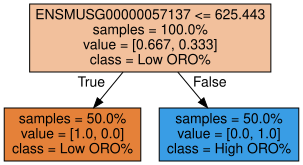

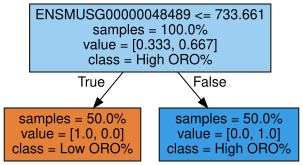

Logistic regression: 
train accuracy: 1.0
test accuracy: 0.3333333333333333


In [ ]:
#make random forest...47 dataset
max_depth=4
clf=m.RandomForestClassifier(max_depth=max_depth,random_state=42)
clf.fit(X_47_train,y_47_train)

y_train_pred_47 = clf.predict(X_47_train)
train_acc_47 = m.accuracy_score(y_47_train, y_train_pred_47)
print("Random Forest")
print("train accuracy:", train_acc_47)

y_pred_47 = clf.predict(X_47_test)
accuracy = m.accuracy_score(y_47_test, y_pred_47)
print("test accuracy:", accuracy)
num_trees=2
for i in range(num_trees):
    tree = clf.estimators_[i]
    dot_data = m.export_graphviz(tree,
                               feature_names=X_47_train.columns,
                               class_names=['Low ORO%',"High ORO%"],
                               filled=True,
                               impurity=False,
                               proportion=True)
    graph = m.graphviz.Source(dot_data)
    display(graph)

#Logistic regression:
print("Logistic regression: ")
clf = m.LogisticRegression(random_state=2)
clf.fit(X_47_train, y_47_train)

y_train_pred = clf.predict(X_47_train)
train_acc = m.accuracy_score(y_47_train, y_train_pred)
print("train accuracy:", train_acc)

y_pred = clf.predict(X_47_test)
accuracy = m.accuracy_score(y_47_test, y_pred)
print("test accuracy:", accuracy)

# confusion_matrix(y_47_test,y_pred)

Random Forest
train accuracy: 1.0
test accuracy: 0.75


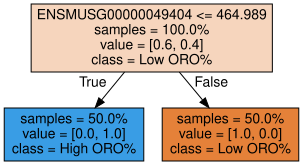

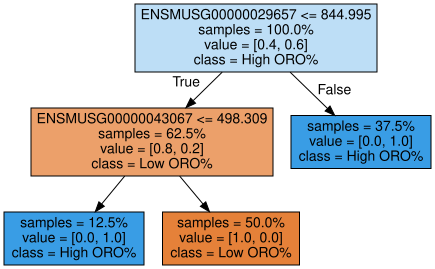

Logistic regression: 
train accuracy: 1.0
test accuracy: 0.75


In [ ]:
#make random forest... 48 dataset
max_depth=4
clf=m.RandomForestClassifier(max_depth=max_depth,random_state=23)
clf.fit(X_48_train,y_48_train)

y_train_pred = clf.predict(X_48_train)
train_acc = m.accuracy_score(y_48_train, y_train_pred)
print("Random Forest")
print("train accuracy:", train_acc)

y_pred = clf.predict(X_48_test)
accuracy = m.accuracy_score(y_48_test, y_pred)
print("test accuracy:", accuracy)
num_trees=2
for i in range(num_trees):
    tree = clf.estimators_[i]
    dot_data = m.export_graphviz(tree,
                               feature_names=X_48_train.columns,
                               class_names=['Low ORO%',"High ORO%"],
                               filled=True,
                               impurity=False,
                               proportion=True)
    graph = m.graphviz.Source(dot_data)
    display(graph)


#Logistic regression:
print("Logistic regression: ")
clf = m.LogisticRegression(random_state=23)
clf.fit(X_48_train, y_48_train)

y_train_pred = clf.predict(X_48_train)
train_acc = m.accuracy_score(y_48_train, y_train_pred)
print("train accuracy:", train_acc)

y_pred = clf.predict(X_48_test)
accuracy = m.accuracy_score(y_48_test, y_pred)
print("test accuracy:", accuracy)




# Hypothesis Testing & Applying Methods for Visualization :

Hypothesis Testing (at a 95% confidence level):

Null Hypothesis: There is no difference in ORO% between Spaceflight and Ground Samples
* H0:μ(Flight Sample ORO%) = μ(Nonflight Sample ORO%)

Alternative Hypothesis: There IS a difference in ORO% between Spaceflight and Ground Samples
* HA: μ(Flight Sample ORO%) ≠ μ(Nonflight Sample ORO%)


Test used: 2-sample independent t-test
Samples are of different sizes, unequal variance assumed

Viewing ORO% of Flight and All Nonflight Samples using Boxplots

OSDR-47 data:
Observed field:  ORO Positivity (%) Excluding Samples:  []
n flight =  5
n nonflight =  10
P-Value:  0.03433
OSDR-48 data:
Observed field:  ORO Positivity (%) Excluding Samples:  []
n flight =  7
n nonflight =  17
P-Value:  0.03921


Text(0.5, 1.0, 'ORO% Between Spaceflight and All Nonflight Samples')

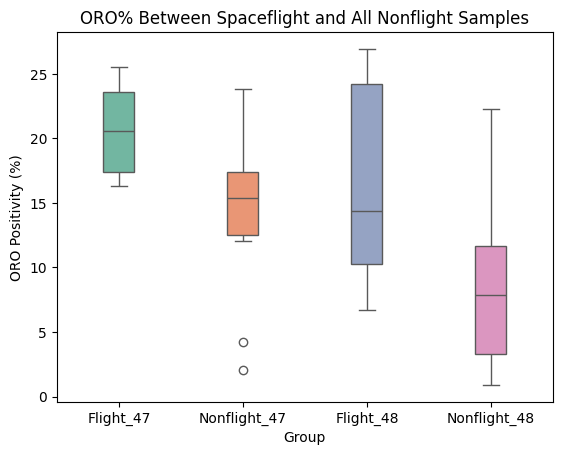

In [ ]:
print("OSDR-47 data:")
df_47box=m.plotbox_summary(source=data['ORO-47'],sample_key='Spaceflight',field='ORO Positivity (%)',treatment='Spaceflight',space='Flight',exclude_samples=[])
df_47box
boxplot47=pd.DataFrame(df_47box,columns=["Flight_47","Nonflight_47"])
boxplot47

####
print("OSDR-48 data:")
df_48box=m.plotbox_summary(source=data['ORO-48'],sample_key='Spaceflight',field='ORO Positivity (%)',treatment='Spaceflight',space='Flight',exclude_samples=[])
df_48box
boxplot48=pd.DataFrame(df_48box,columns=["Flight_48","Nonflight_48"])
boxplot48
###
df_toplot48=boxplot48.melt(var_name="Group",value_name="ORO Positivity (%)")
df_toplot48
###
df_toplot47=boxplot47.melt(var_name="Group",value_name="ORO Positivity (%)")
df_toplot47
###
df_toplot=pd.concat([df_toplot47,df_toplot48])
df_toplot=df_toplot.reset_index(drop=True)
df_toplot
ax=sns.boxplot(data=df_toplot,x="Group",y="ORO Positivity (%)",palette="Set2",width=0.25)
ax.set_title("ORO% Between Spaceflight and All Nonflight Samples")

Viewing ORO% Between Flight & Ground Control Samples Through Boxplots

OSDR-47 Samples Data:
Observed field:  ORO Positivity (%) Excluding Samples:  ['Basal']
n flight =  5
n nonflight =  5
P-Value:  0.02574
OSDR-48 Samples data:
Observed field:  ORO Positivity (%) Excluding Samples:  ['Basal', 'Vivarium']
n flight =  7
n nonflight =  7
P-Value:  0.012


Text(0.5, 1.0, 'ORO% Between Spaceflight and Ground Control Samples')

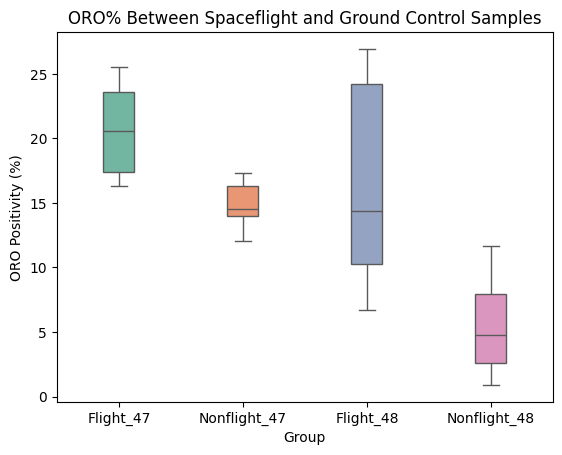

In [ ]:
print("OSDR-47 Samples Data:")
df_47box=m.plotbox_summary(source=data['ORO-47'],sample_key='Spaceflight',field='ORO Positivity (%)',treatment='Spaceflight',space='Flight',exclude_samples=['Basal'])
df_47box
boxplot47=pd.DataFrame(df_47box,columns=["Flight_47","Nonflight_47"])
boxplot47

####
print( "OSDR-48 Samples data:")
df_48box=m.plotbox_summary(source=data['ORO-48'],sample_key='Spaceflight',field='ORO Positivity (%)',treatment='Spaceflight',space='Flight',exclude_samples=['Basal','Vivarium'])
df_48box
boxplot48=pd.DataFrame(df_48box,columns=["Flight_48","Nonflight_48"])
boxplot48
###
df_toplot48=boxplot48.melt(var_name="Group",value_name="ORO Positivity (%)")
df_toplot48
###
df_toplot47=boxplot47.melt(var_name="Group",value_name="ORO Positivity (%)")
df_toplot47
###
df_toplot=pd.concat([df_toplot47,df_toplot48])
df_toplot=df_toplot.reset_index(drop=True)
df_toplot
ax=sns.boxplot(data=df_toplot,x="Group",y="ORO Positivity (%)",palette="Set2",width=0.25)
ax.set_title("ORO% Between Spaceflight and Ground Control Samples")

At a 95% level of significance, we reject the null hypothesis if the p-value < 0.05

After conducting 2-sample independent t-tests, between Flight and ground samples for both OSDR-47 and OSDR-48 flight/nonflight samples, each time we get a p-value < 0.05.

* OSD-47 Flight/NonFlight P-value: 0.03433   < 0.05
* OSD-48 Flight/NonFlight P-value: 0.03921  < 0.05
* OSD-47 Flight/Ground Control P-val: 0.02574    < 0.05
* OSD-48 Flight/Ground Control P-val: 0.012    < 0.05


 We can thus conclude that there is evidence to suggest that there is a significant difference in ORO% between flight and nonflight samples.

This is an indicator that spaceflight affects mice and causes increased level of lipids to be stored in the liver. Mice are studied due to their genomic similarity with humans. The increase in lipid storage in the liver is a concern that must be considered when sending astronauts into space. Increased lipid storage in the liver may cause a variety of problems, like Non-alcoholic fatty liver disease, which may cause liver damage and a variety of issues, including changes in metabolism.


# Volcano plots!

In [ ]:
test47=m.dgea_table(data['47-normalized'],metadata['47'],pval=0.05,l2fc=0)
test47=test47.reset_index()
test47

Fitting size factors...
... done in 0.02 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 25.45 seconds.

Fitting dispersion trend curve...
... done in 0.64 seconds.

Fitting MAP dispersions...
... done in 34.94 seconds.

Fitting LFCs...
... done in 15.39 seconds.

Calculating cook's distance...
... done in 0.03 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 5.66 seconds.



Log2 fold change & Wald test p-value: condition 0 vs 1
                        baseMean  log2FoldChange     lfcSE      stat  \
ENSMUSG00000000001   2647.889712       -0.003579  0.141372 -0.025314   
ENSMUSG00000000028     41.979262        0.318747  0.251090  1.269454   
ENSMUSG00000000031     31.374497       -0.401640  0.384983 -1.043267   
ENSMUSG00000000049  54010.994105       -0.061213  0.111358 -0.549700   
ENSMUSG00000000056   1577.044127       -0.287090  0.286038 -1.003681   
...                          ...             ...       ...       ...   
ENSMUSG00000118346    304.911145        0.025182  0.145998  0.172485   
ENSMUSG00000118353    153.895788       -0.020889  0.350203 -0.059649   
ENSMUSG00000118366   3126.113732       -0.104616  0.100654 -1.039364   
ENSMUSG00000118383      6.187960       -0.586585  1.034449 -0.567051   
ENSMUSG00000118386      2.319109        0.862256  1.289663  0.668590   

                      pvalue      padj  
ENSMUSG00000000001  0.979804  0.999994 

,index,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
0,ENSMUSG00000000001,2647.889712,-0.003579,0.141372,-0.025314,0.979804,0.999994
1,ENSMUSG00000000028,41.979262,0.318747,0.251090,1.269454,0.204279,0.999994
2,ENSMUSG00000000031,31.374497,-0.401640,0.384983,-1.043267,0.296825,0.999994
3,ENSMUSG00000000049,54010.994105,-0.061213,0.111358,-0.549700,0.582525,0.999994
4,ENSMUSG00000000056,1577.044127,-0.287090,0.286038,-1.003681,0.315532,0.999994
...,...,...,...,...,...,...,...
20488,ENSMUSG00000118346,304.911145,0.025182,0.145998,0.172485,0.863056,0.999994
20489,ENSMUSG00000118353,153.895788,-0.020889,0.350203,-0.059649,0.952435,0.999994
20490,ENSMUSG00000118366,3126.113732,-0.104616,0.100654,-1.039364,0.298636,0.999994
20491,ENSMUSG00000118383,6.187960,-0.586585,1.034449,-0.567051,0.570680,0.999994


In [ ]:
test48=m.dgea_table(data['48-normalized'],metadata['48'],pval=0.05,l2fc=0)
test48=test48.reset_index()
test48

Fitting size factors...
... done in 0.02 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 28.33 seconds.

Fitting dispersion trend curve...
... done in 0.68 seconds.

Fitting MAP dispersions...
... done in 37.43 seconds.

Fitting LFCs...
... done in 18.61 seconds.

Calculating cook's distance...
... done in 0.03 seconds.

Replacing 988 outlier genes.

Fitting dispersions...
... done in 0.80 seconds.

Fitting MAP dispersions...
... done in 0.80 seconds.

Fitting LFCs...
... done in 0.62 seconds.

Running Wald tests...
... done in 7.40 seconds.



Log2 fold change & Wald test p-value: condition 0 vs 1
                        baseMean  log2FoldChange     lfcSE      stat  \
ENSMUSG00000000001   1684.650541       -0.005072  0.180909 -0.028038   
ENSMUSG00000000028     19.100214        0.374323  0.351912  1.063683   
ENSMUSG00000000031     19.119565        0.160855  0.443769  0.362475   
ENSMUSG00000000037      2.207952        0.093022  1.820465  0.051098   
ENSMUSG00000000049  47181.157649        0.062272  0.127950  0.486695   
...                          ...             ...       ...       ...   
ENSMUSG00000118353    150.122670       -0.096266  0.349092 -0.275761   
ENSMUSG00000118366   1970.577908        0.139133  0.132072  1.053460   
ENSMUSG00000118383      7.445572        1.250616  0.708094  1.766171   
ENSMUSG00000118384      2.063269       -0.104333  1.368020 -0.076266   
ENSMUSG00000118386      1.636523       -0.123877  1.332722 -0.092950   

                      pvalue      padj  
ENSMUSG00000000001  0.977632  0.998446 

,index,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
0,ENSMUSG00000000001,1684.650541,-0.005072,0.180909,-0.028038,0.977632,0.998446
1,ENSMUSG00000000028,19.100214,0.374323,0.351912,1.063683,0.287472,0.998377
2,ENSMUSG00000000031,19.119565,0.160855,0.443769,0.362475,0.716997,0.998377
3,ENSMUSG00000000037,2.207952,0.093022,1.820465,0.051098,0.959247,NaN
4,ENSMUSG00000000049,47181.157649,0.062272,0.127950,0.486695,0.626475,0.998377
...,...,...,...,...,...,...,...
22191,ENSMUSG00000118353,150.122670,-0.096266,0.349092,-0.275761,0.782732,0.998377
22192,ENSMUSG00000118366,1970.577908,0.139133,0.132072,1.053460,0.292130,0.998377
22193,ENSMUSG00000118383,7.445572,1.250616,0.708094,1.766171,0.077367,0.804112
22194,ENSMUSG00000118384,2.063269,-0.104333,1.368020,-0.076266,0.939208,NaN


In [ ]:
vol_47=data['47-normalized']
foldchanges47=list(test47['log2FoldChange'])
transformed_pvals47=list(-1*np.log10(test47['pvalue']))
plot_title="Gene Expression in Nonflight vs. Flight Samples in OSDR-47"
x_axis_title="log2(fold change)"
y_axis_title="-log10(p-value)"
x_axis="log2(fold change)"
y_axis="-log10(p-value)"
point_radius=6
fig_47=go.Figure()
fig_47.update_layout(
    title=plot_title,
    xaxis_title=x_axis,
    yaxis_title=y_axis,
    paper_bgcolor='white',
    plot_bgcolor='white'
)
colors_47=[]
expressed_47=[]
for i in range(0,len(foldchanges47)):
  if transformed_pvals47[i]>2:
    if foldchanges47[i]>0.5:
      colors_47.append('darkred')
      expressed_47.append(vol_47['Unnamed: 0'][i])
    elif foldchanges47[i]<-0.5:
      colors_47.append('navy')
      expressed_47.append(vol_47['Unnamed: 0'][i])
    else:
      colors_47.append('grey')
  else:
    colors_47.append('lightgrey')
fig_47.add_trace(
    go.Scattergl(
        x=foldchanges47,y=transformed_pvals47,mode='markers',text=vol_47.iloc[:,0].values.tolist(),
        hovertemplate='%{text}: %{x} (fc)<br>%{y}(p-val)<extra></extra>',showlegend=False,
        marker={'color':colors_47,'size':point_radius},marker_opacity=0.7
    )
)
#fig_47.show()
print("Expressed count: ",len(expressed_47))
dgeaexpressed_47=rna_seq_47['Unnamed: 0']
overlap=set(expressed_47) & set(dgeaexpressed_47)
print("Overlap: ",len(overlap))
print(overlap)

most_exp_47=(test47[test47.iloc[:,0].isin(overlap)]).sort_values(by='padj')
most_exp_15_47=most_exp_47.head(15)
print(most_exp_15_47['index'])



top_15_x_47=most_exp_15_47['log2FoldChange']
top_15_y_47=-np.log10(most_exp_15_47['pvalue'])
top_15_text_47=most_exp_15_47['index']
top15_cols_47=[]
for fold in top_15_x_47:

  if fold>0:
      top15_cols_47.append('darkred')
  elif fold<0:
      top15_cols_47.append('navy')
fig_47.add_traces(
    go.Scattergl(x=top_15_x_47,y=top_15_y_47,text=top_15_text_47,marker_symbol='star',marker_size=10,mode='markers',marker_opacity=1, marker={'color':top15_cols_47},showlegend=False))
fig_47.update_layout(
 annotations=[
      dict(x=1.0,y=1.25,xref='paper',yref='paper',text="Legend:",align="left",font=dict(color="black"),showarrow=False),
      dict(x=.95,y=1.12,xref='paper',yref='paper',text="•",align="left",font=dict(color="navy"),showarrow=False),
      dict(x=.95,y=1.17,xref='paper',yref='paper',text="•",align="left",font=dict(color="darkred"),showarrow=False),

      dict(x=1.05,y=1.12,xref='paper',yref='paper',text="Underexpressed",align="left",font=dict(color="navy"),showarrow=False),
      dict(x=1.044,y=1.17,xref='paper',yref='paper',text="Overexpressed",align="left",font=dict(color="darkred"),showarrow=False)

     ]   )
fig_47.show()

fc=np.array(foldchanges47)
pval = np.array(transformed_pvals47)

sig_up = np.sum((pval > 2) & (fc > 0.5))
sig_down = np.sum((pval > 2) & (fc < -0.5))
sig_neutral = np.sum((pval > 2) & (np.abs(fc) <= 0.5))
non_sig = np.sum(pval <= 2)

print(f"Significant upregulated (red): {sig_up}")
print(f"Significant downregulated (blue): {sig_down}")
print(f"Significant w low fc (grey): {sig_neutral}")
print(f"insignificant (light grey): {non_sig}")

Expressed count:  124
Overlap:  2
{'ENSMUSG00000057137', 'ENSMUSG00000048489'}
12826    ENSMUSG00000057137
11612    ENSMUSG00000048489
Name: index, dtype: object


Significant upregulated (red): 89
Significant downregulated (blue): 35
Significant w low fc (grey): 54
insignificant (light grey): 20244


In [ ]:
voldf=data['48-normalized']
foldchanges1=list(test48['log2FoldChange'])
transformed_pvals1=-np.log10(test48['pvalue'])
plot_title="Gene Expression in Nonflight vs. Flight Samples in OSDR-48"
x_axis_title="log2(fold change)"
y_axis_title="-log10(p-value)"
point_radius=6
fig=go.Figure()
fig.update_layout(
    title=plot_title,
    xaxis_title=x_axis_title,
    yaxis_title=y_axis_title,
    paper_bgcolor='white',
    plot_bgcolor='white'
)

colors=[]
expressed=[]
for i in range(0,len(foldchanges1)):
  if transformed_pvals1[i]>2:
    if foldchanges1[i]>0.5:
      colors.append('red')
      expressed.append(voldf['Unnamed: 0'][i])
    elif foldchanges1[i]<-0.5:
      colors.append('blue')
      expressed.append(voldf['Unnamed: 0'][i])
    else:
      colors.append('grey')
  else:
    colors.append('lightgrey')

fig.add_trace(
    go.Scattergl(
        x=foldchanges1,y=transformed_pvals1,mode='markers',text=voldf.iloc[:,0].values.tolist(),
        hovertemplate='%{text}: %{x} (fc)<br>%{y}(p-val)<extra></extra>',showlegend=False,
        marker={'color':colors,'size':point_radius},marker_opacity=0.5
    )
)


print("Expressed count: ",len(expressed))
dgeaexpressed=rna_seq_48['Unnamed: 0']
overlap=set(expressed) & set(dgeaexpressed)
print("Overlap: ",len(overlap))
# print(overlap)

most_exp_48=(test48[test48.iloc[:,0].isin(overlap)]).sort_values(by='padj')
most_exp_15_48=most_exp_48.head(15)
# print(most_exp_15['index'])

top_15_x_48=most_exp_15_48['log2FoldChange']
top_15_y_48=-np.log10(most_exp_15_48['pvalue'])
top_15_text_48=most_exp_15_48['index']
top15_cols_48=[]
for fold in top_15_x_48:

  if fold>0:
      top15_cols_48.append('red')
  elif fold<0:
      top15_cols_48.append('blue')
fig.add_traces(
    go.Scattergl(x=top_15_x_48,y=top_15_y_48,text=top_15_text_48,marker_symbol='star',marker_size=10,mode='markers',marker_opacity=1, marker={'color':top15_cols_48},showlegend=False))
#annotated legend
fig.update_layout(
 annotations=[
      dict(x=1.0,y=1.25,xref='paper',yref='paper',text="Legend:",align="left",font=dict(color="black"),showarrow=False),
      dict(x=.95,y=1.12,xref='paper',yref='paper',text="•",align="left",font=dict(color="blue"),showarrow=False),
      dict(x=.95,y=1.17,xref='paper',yref='paper',text="•",align="left",font=dict(color="red"),showarrow=False),

      dict(x=1.05,y=1.12,xref='paper',yref='paper',text="Underexpressed",align="left",font=dict(color="blue"),showarrow=False),
      dict(x=1.044,y=1.17,xref='paper',yref='paper',text="Overexpressed",align="left",font=dict(color="red"),showarrow=False)

     ]   )
fig.show()


fc=np.array(foldchanges1)
pval = np.array(transformed_pvals1)

sig_up = np.sum((pval > 2) & (fc > 0.5))
sig_down = np.sum((pval > 2) & (fc < -0.5))
sig_neutral = np.sum((pval > 2) & (np.abs(fc) <= 0.5))
non_sig = np.sum(pval <= 2)

print(f"Significant upregulated (red): {sig_up}")
print(f"Significant downregulated (blue): {sig_down}")
print(f"Significant w low fc (grey): {sig_neutral}")
print(f"insignificant (light grey): {non_sig}")


Expressed count:  347
Overlap:  85


Significant upregulated (red): 155
Significant downregulated (blue): 192
Significant w low fc (grey): 83
insignificant (light grey): 21611


In [ ]:
plot_title="Genes Expressed Significantly Between Flight & Nonflight Samples in OSDR-47 and OSDR-48" #genes expressed significantly across flight & Nonflight samples??
#Gene Expression in Nonflight vs. Flight Samples
x_axis_title="log2(fold change)"
y_axis_title="-log10(p-value)"
point_radius=6
fig_combined=go.Figure()
fig_combined.update_layout(
    title=plot_title,
    xaxis_title=x_axis_title,
    yaxis_title=y_axis_title,
    paper_bgcolor='white',
    plot_bgcolor='white'
)
fig_combined.add_trace(
    go.Scattergl(
        x=foldchanges47,y=transformed_pvals47,mode='markers',text=vol_47.iloc[:,0].values.tolist(),
        hovertemplate='%{text}: %{x} (fc)<br>%{y}(p-val)<extra></extra>',showlegend=False,
        marker={'color':colors_47,'size':point_radius},marker_opacity=0.5
    )
)
fig_combined.add_traces(
    go.Scattergl(x=top_15_x_47,y=top_15_y_47,text=top_15_text_47,marker_symbol='star',marker_size=10,mode='markers',marker_opacity=1, marker={'color':top15_cols_47},showlegend=False))


fig_combined.add_trace(
    go.Scattergl(
        x=foldchanges1,y=transformed_pvals1,mode='markers',text=voldf.iloc[:,0].values.tolist(),
        hovertemplate='%{text}: %{x} (fc)<br>%{y}(p-val)<extra></extra>',showlegend=False,
        marker={'color':colors,'size':point_radius},marker_opacity=0.5
    )
)

fig_combined.add_traces(
    go.Scattergl(x=top_15_x_48,y=top_15_y_48,text=top_15_text_48,marker_symbol='star',marker_size=10,mode='markers',marker_opacity=1, marker={'color':top15_cols_48},showlegend=False))
#Legend Annotations
fig_combined.update_layout(
 annotations=[
      dict(x=1.0,y=1.25,xref='paper',yref='paper',text="Legend:",align="left",font=dict(color="black"),showarrow=False),
      dict(x=.95,y=1.2,xref='paper',yref='paper',text="•",align="left",font=dict(color="blue"),showarrow=False),
      dict(x=.95,y=1.15,xref='paper',yref='paper',text="•",align="left",font=dict(color="red"),showarrow=False),
      dict(x=.95,y=1.1,xref='paper',yref='paper',text="•",align="left",font=dict(color="navy"),showarrow=False),
      dict(x=.95,y=1.05,xref='paper',yref='paper',text="•",align="left",font=dict(color="darkred"),showarrow=False),
      dict(x=.95,y=1.0,xref='paper',yref='paper',text="•",align="left",font=dict(color="grey"),showarrow=False),

      dict(x=1.05,y=1.2,xref='paper',yref='paper',text="Underexpressed(48)",align="left",font=dict(color="blue"),showarrow=False),
      dict(x=1.044,y=1.15,xref='paper',yref='paper',text="Overexpressed(48)",align="left",font=dict(color="red"),showarrow=False),
      dict(x=1.05,y=1.1,xref='paper',yref='paper',text="Underexpressed(47)",align="left",font=dict(color="navy"),showarrow=False),
      dict(x=1.044,y=1.05,xref='paper',yref='paper',text="Overexpressed(47)",align="left",font=dict(color="darkred"),showarrow=False),
      dict(x=1.05,y=1.0,xref='paper',yref='paper',text="Insignificant/Neutral",align="left",font=dict(color="grey"),showarrow=False)

     ]
)

fig_combined.show()

# Tabulating Expressed Gene Information

In [ ]:
#Combined DF of most sig genes from both OSDR47 and OSDR 48 sorted by significance.
combined_expressed=pd.merge(most_exp_15_47,most_exp_15_48,how='outer')
combined_expressed=combined_expressed.sort_values(by='padj',ignore_index=True)

In [ ]:
mg = mygene.MyGeneInfo()
expressedgeneIDs=list(combined_expressed['index'])

genedata=mg.getgenes(expressedgeneIDs,fields='name,symbol,summary,type_of_gene',as_dataframe=True)
GeneInfo=pd.DataFrame({"Gene ID":expressedgeneIDs,"Symbol":genedata['symbol'],"Name":genedata["name"],"Summary":genedata['summary'],"Gene Type":genedata['type_of_gene']})
GeneInfo.reset_index(drop=True,inplace=True)

list_of_links=list()
for gene in GeneInfo['Gene ID']:
  gene_id_link = "https://www.ncbi.nlm.nih.gov/gene/?term="+gene+"#gene-expression"
  list_of_links.append(gene_id_link)
GeneInfo['Link']=list_of_links
GeneInfo.style.format({'Link':m.clickable_format}) #display df with links



INFO:biothings.client:querying 1-17 ...


,Gene ID,Symbol,Name,Summary,Gene Type,Link
0,ENSMUSG00000110384,nan,nan,nan,nan,https://www.ncbi.nlm.nih.gov/gene/?term=ENSMUSG00000110384#gene-expression
1,ENSMUSG00000028957,Per3,period circadian clock 3,"This gene is a member of the Period family of genes and is expressed in a circadian pattern in the suprachiasmatic nucleus, the primary circadian pacemaker in the mammalian brain. Genes in this family encode components of the circadian rhythms of locomotor activity, metabolism, and behavior. This gene is upregulated by Clock/Arntl heterodimers but then represses this upregulation in a feedback loop using Per/Cry heterodimers to interact with Clock/Arntl. Polymorphisms in this gene have been linked to sleep disorders. Multiple transcript variants encoding different isoforms have been found for this gene. [provided by RefSeq, Feb 2014].",protein-coding,https://www.ncbi.nlm.nih.gov/gene/?term=ENSMUSG00000028957#gene-expression
2,ENSMUSG00000023067,Cdkn1a,cyclin dependent kinase inhibitor 1A,"This gene encodes a potent cyclin-dependent kinase inhibitor. The encoded protein binds to and inhibits the activity of cyclin-cyclin-dependent kinase2 or cyclin-dependent kinase4 complexes, and thus functions as a regulator of cell cycle progression at the G1 pahse. The expression of this gene is tightly controlled by the tumor suppressor protein p53, through which this protein mediates the p53-dependent cell cycle G1 phase arrest in response to a variety of stress stimuli. This protein can interact with proliferating cell nuclear antigen, a DNA polymerase accessory factor, and plays a regulatory role in S phase DNA replication and DNA damage repair. This protein was reported to be specifically cleaved by CASP3-like caspases, which thus leads to a dramatic activation of cyclin-dependent kinase2, and may be instrumental in the execution of apoptosis following caspase activation. Mice that lack this gene have the ability to regenerate damaged or missing tissue. Alternative splicing results in multiple transcript variants. [provided by RefSeq, Sep 2015].",protein-coding,https://www.ncbi.nlm.nih.gov/gene/?term=ENSMUSG00000023067#gene-expression
3,ENSMUSG00000020108,Ddit4,DNA-damage-inducible transcript 4,nan,protein-coding,https://www.ncbi.nlm.nih.gov/gene/?term=ENSMUSG00000020108#gene-expression
4,ENSMUSG00000026435,Slc45a3,"solute carrier family 45, member 3",nan,protein-coding,https://www.ncbi.nlm.nih.gov/gene/?term=ENSMUSG00000026435#gene-expression
5,ENSMUSG00000041698,Slco1a1,"solute carrier organic anion transporter family, member 1a1",nan,protein-coding,https://www.ncbi.nlm.nih.gov/gene/?term=ENSMUSG00000041698#gene-expression
6,ENSMUSG00000059824,Dbp,D site albumin promoter binding protein,"The protein encoded by this gene is a member of the Par bZIP transcription factor family and binds to specific sequences in the promoters of several genes, such as albumin, Cyp2a4, and Cyp2a5. The encoded protein can bind DNA as a homo- or heterodimer and is involved in the regulation of some circadian rhythym genes. [provided by RefSeq, Feb 2014].",protein-coding,https://www.ncbi.nlm.nih.gov/gene/?term=ENSMUSG00000059824#gene-expression
7,ENSMUSG00000025078,Nhlrc2,NHL repeat containing 2,nan,protein-coding,https://www.ncbi.nlm.nih.gov/gene/?term=ENSMUSG00000025078#gene-expression
8,ENSMUSG00000029167,Ppargc1a,"peroxisome proliferative activated receptor, gamma, coactivator 1 alpha","This gene encodes a transcriptional coactivator that induces and coordinates gene expression regulating mitochondrial biogenesis, respiration, hepatic gluconeogenesis, thermogenic program in brown fat and muscle fiber-type switching. Mice lacking the encoded protein exhibit reduced thermogenic capacity, hyperactivity and resistance to diet-induced obesity. Mice lacking the encoded protein specifically in the heart exhibit peripartum cardiomyopathy. Alternative splicing results in multiple transcript variants. [provided by RefSeq, Sep 2015].",protein-coding,https://ww